In [1]:
pip install --upgrade imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [4]:
# Libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipaddress
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from imblearn.over_sampling import SMOTE

In [5]:
#Load the chosen dataset
df = pd.read_csv("cybersecurity_attacks.csv", parse_dates=['Timestamp'])

In [6]:
#Display the first 05 records in chosen dataset
df.head().T
#Dimension of the Dataset
print("Dimension (No.of Rows, No.of Columns) of the Dataset: ", df.shape)
#Dataset Information: Dimension, Column Names & its count, data types
df.info()
#Dataset Description: Statistical summary for numerical columns of the dataset
df.describe().T

Dimension (No.of Rows, No.of Columns) of the Dataset:  (2348, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2348 entries, 0 to 2347
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Timestamp               2348 non-null   datetime64[ns]
 1   Source IP Address       2348 non-null   object        
 2   Destination IP Address  2348 non-null   object        
 3   Source Port             2348 non-null   int64         
 4   Destination Port        2348 non-null   int64         
 5   Protocol                2348 non-null   object        
 6   Packet Length           2348 non-null   int64         
 7   Packet Type             2348 non-null   object        
 8   Traffic Type            2348 non-null   object        
 9   Payload Data            2348 non-null   object        
 10  Malware Indicators      1172 non-null   object        
 11  Anomaly Scores          2348 non-null   fl

,count,mean,min,25%,50%,75%,max,std
Timestamp,2348,2021-11-23 05:15:31.725298176,2020-01-01 04:19:53,2020-12-04 05:30:59,2021-11-23 18:08:52,2022-11-12 00:46:27.750000128,2023-10-11 06:42:19,NaN
Source Port,2348.0,32314.99276,1031.0,15965.5,31733.0,48357.0,65521.0,18781.241745
Destination Port,2348.0,32838.227428,1030.0,17096.25,32502.0,49076.5,65535.0,18571.544069
Packet Length,2348.0,788.548552,64.0,428.75,786.0,1143.25,1500.0,413.974742
Anomaly Scores,2348.0,50.104647,0.06,24.6575,50.52,75.16,99.99,28.932539


Information on Frequncy of Attacks


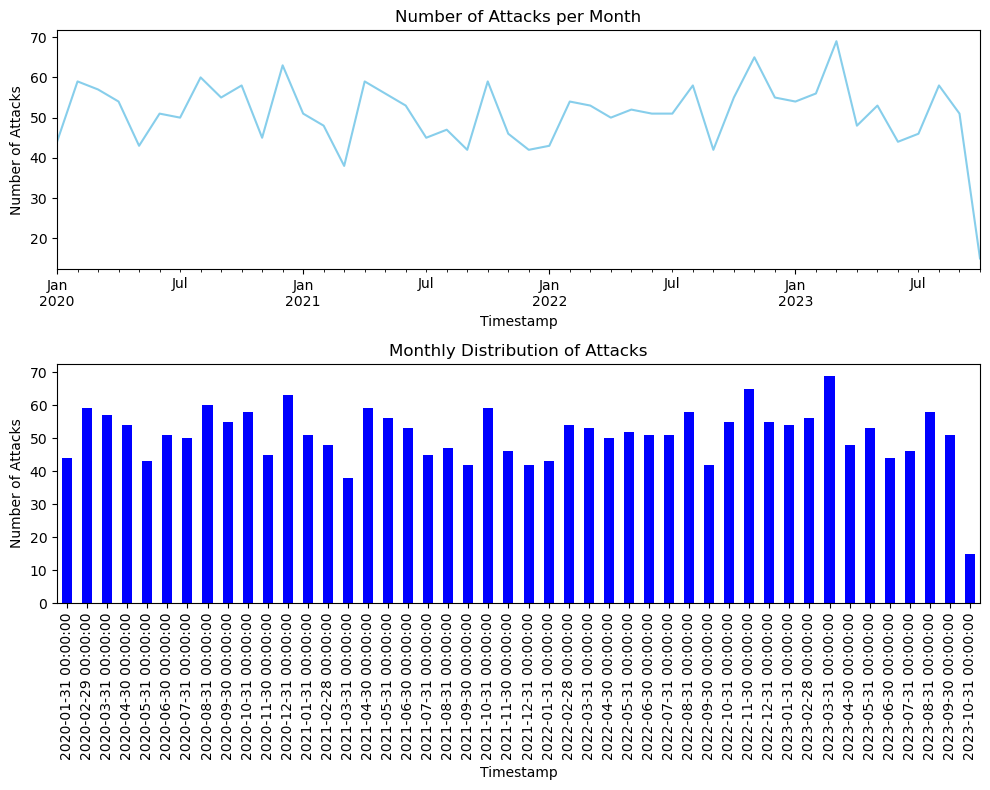

In [7]:
#Frequency of Attacks
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
monthly_attacks = df.resample('ME', on='Timestamp')['Attack Type'].count()
print("Information on Frequncy of Attacks")
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
monthly_attacks.plot(ax=ax[0], color='skyblue')
ax[0].set_title('Number of Attacks per Month')
ax[0].set_ylabel('Number of Attacks')
monthly_attacks.plot(kind='bar', ax=ax[1], color='blue')
ax[1].set_title('Monthly Distribution of Attacks')
ax[1].set_ylabel('Number of Attacks')
plt.tight_layout()
plt.show()

Summary of the No.of Attacks Year wise
 Attack Type  DDoS  Intrusion  Malware
Year                                 
2020          221        217      201
2021          177        207      202
2022          220        202      207
2023          182        143      169


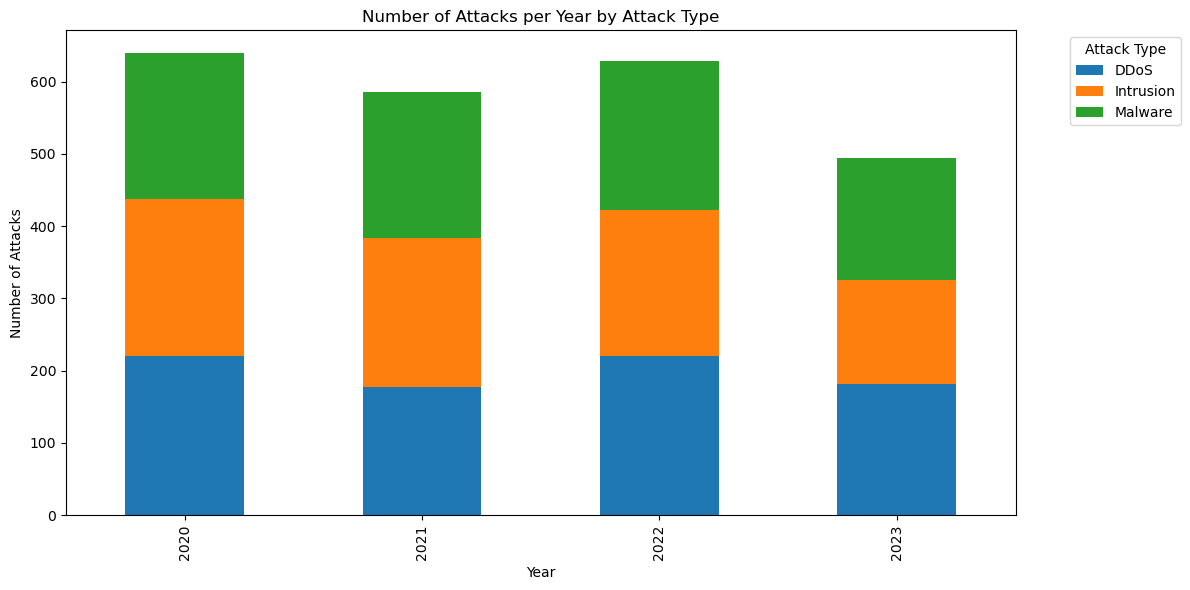

In [8]:
#Number of Attacks per year
df['Year']=df['Timestamp'].dt.year
# Group by YEAR and ATTACK TYPE, count occurrences
attack_counts = df.groupby(['Year', 'Attack Type']).size().unstack(fill_value=0)
# Print a summary of the data
print("Summary of the No.of Attacks Year wise\n",attack_counts)
# Plot the data
ax = attack_counts.plot(kind='bar', stacked=True, figsize=(12, 6))
# Customize the plot
plt.title('Number of Attacks per Year by Attack Type')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.legend(title='Attack Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

In [9]:
# Add value labels on the bars
for c in ax.containers:
    ax.bar_label(c, label_type='center')
# Show the plot
plt.show()

  Protocol Attack Type  COUNT
1     ICMP   Intrusion    274
6      UDP        DDoS    269
3      TCP        DDoS    267
8      UDP     Malware    265
0     ICMP        DDoS    264
2     ICMP     Malware    262
5      TCP     Malware    252
7      UDP   Intrusion    250
4      TCP   Intrusion    245


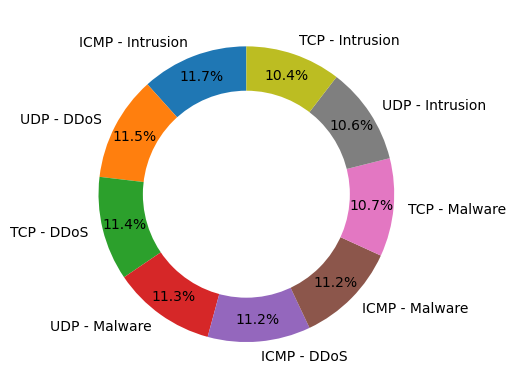

In [10]:
# Count occurrences of each combination of PROTOCOL and ATTACK TYPE
protocol_attack_counts = df.groupby(['Protocol', 'Attack Type']).size().reset_index(name='COUNT')
# Sort by count in descending order and take top 10 for better visibility
top_10 = protocol_attack_counts.sort_values('COUNT', ascending=False).head(10)
# Print a summary of the data
print(top_10)
# Create a pie chart
#ax = attack_counts.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.plot(figsize=(12, 8))
plt.pie(top_10['COUNT'], labels=top_10.apply(lambda x: f"{x['Protocol']} - {x['Attack Type']}", axis=1),
autopct='%1.1f%%', startangle=90, pctdistance=0.85)
# Add a circle at the center to create a donut chart (optional)
center_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(center_circle)

C:\Users\DELL\AppData\Local\Temp\ipykernel_17744\3312269431.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Protocol - Attack Type', loc='center left', bbox_to_anchor=(1, 0, 0.5, 1))


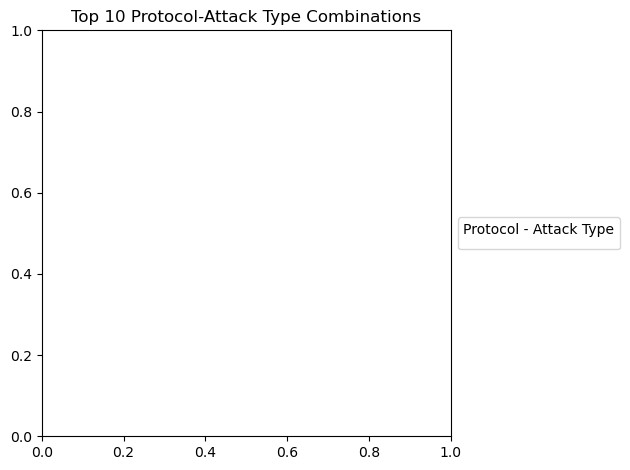

In [11]:
#Add title
plt.title('Top 10 Protocol-Attack Type Combinations')
# Add legend
plt.legend(title='Protocol - Attack Type', loc='center left', bbox_to_anchor=(1, 0, 0.5, 1))
# Adjust layout to prevent cutting off labels
plt.tight_layout()
# Show the plot
plt.show()

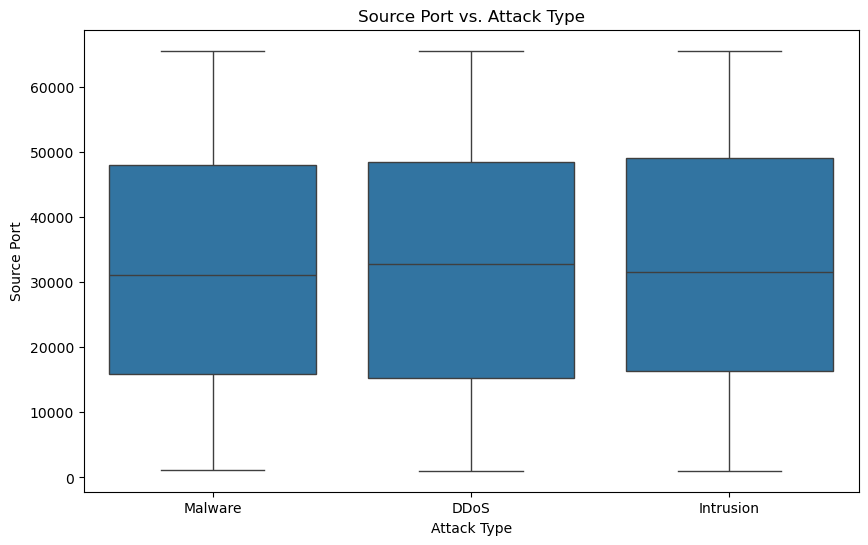

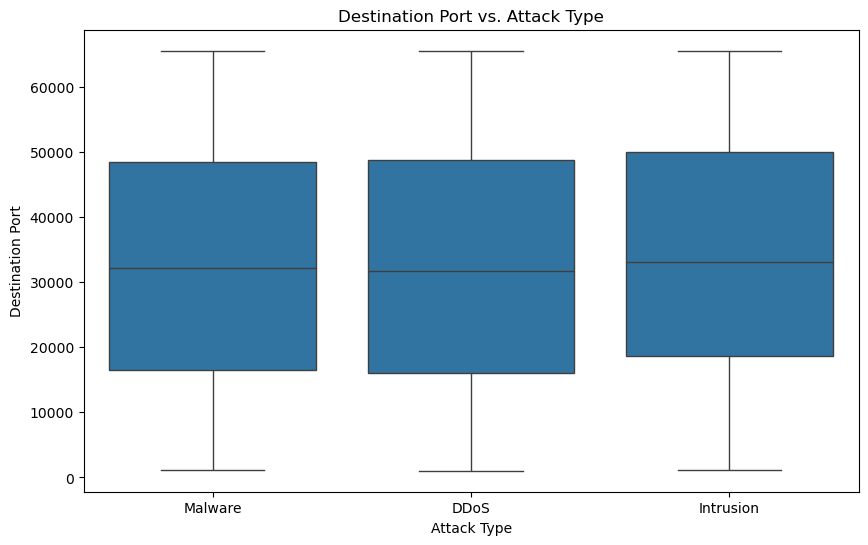

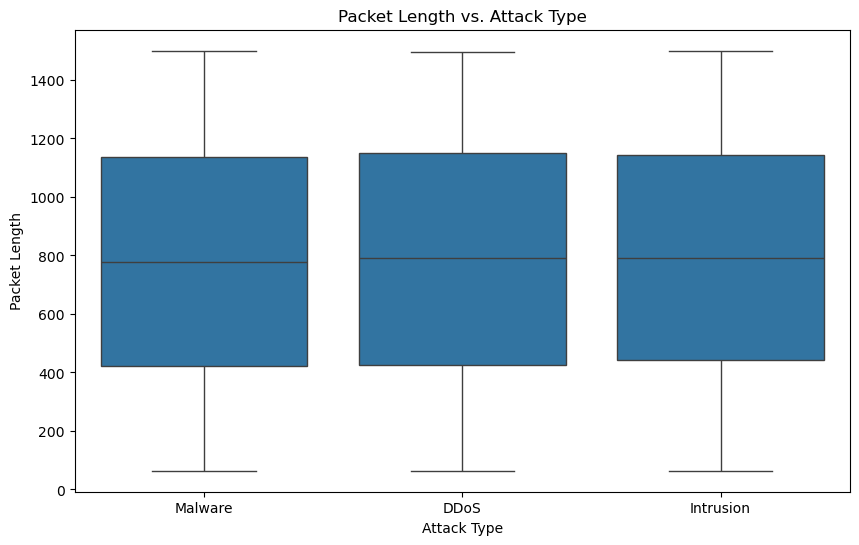

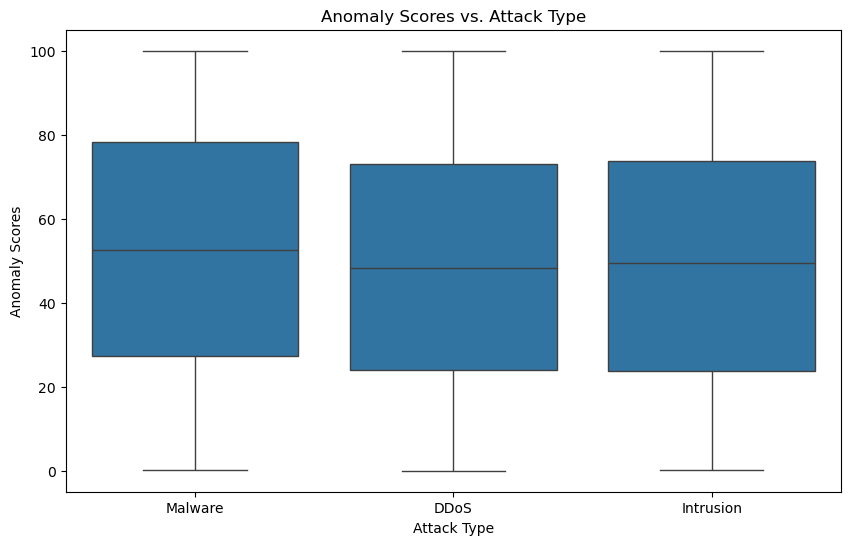

In [12]:
# Explore relationships between features and the target variable
# Select some features for visualization. Adjust based on actual features in your dataset.
features = ['Source Port', 'Destination Port', 'Packet Length', 'Anomaly Scores']
for feature in features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Attack Type', y=feature, data=df)
    plt.title(f'{feature} vs. Attack Type')
    plt.xlabel('Attack Type')
    plt.ylabel(feature)
    plt.show()

In [13]:
#Handling Missing values: Identify the columns with missing values and fill with 0
# Get column names with missing values
columns_with_missing = df.columns[df.isnull().any()].tolist()
# Print the result
print("Columns with missing values:")
for column in columns_with_missing:
    print(column)
# If you want to also see the count of missing values:
print("\nColumns with missing values and their counts:")
for column in columns_with_missing:
    missing_count = df[column].isnull().sum()
    print(f"{column}: {missing_count}")
# Fill the missing values with 0
df = df.fillna(0)
df.info()

Columns with missing values:
Malware Indicators
Alerts/Warnings
Network Segment
Geo-location Data
Proxy Information
Firewall Logs
IDS/IPS Alerts
Log Source

Columns with missing values and their counts:
Malware Indicators: 1176
Alerts/Warnings: 1187
Network Segment: 1
Geo-location Data: 1
Proxy Information: 1148
Firewall Logs: 1197
IDS/IPS Alerts: 1163
Log Source: 1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2348 entries, 0 to 2347
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Timestamp               2348 non-null   datetime64[ns]
 1   Source IP Address       2348 non-null   object        
 2   Destination IP Address  2348 non-null   object        
 3   Source Port             2348 non-null   int64         
 4   Destination Port        2348 non-null   int64         
 5   Protocol                2348 non-null   object        
 6   Packet Length           2348 non-null  

In [14]:
#Convert some of the dataset values into integer
#convert the Timestamp into UNIX Epochs time which is in a long interger format
print("Timestamp values in YYYY-MM-DD HH:MM:SS format, \n",df['Timestamp'])

Timestamp values in YYYY-MM-DD HH:MM:SS format, 
 0      2023-05-30 06:33:58
1      2020-08-26 07:08:30
2      2022-11-13 08:23:25
3      2023-07-02 10:38:46
4      2023-07-16 13:11:07
               ...        
2343   2021-04-28 15:27:26
2344   2020-08-28 05:23:21
2345   2023-07-13 03:46:53
2346   2020-02-28 05:01:36
2347   2022-07-28 04:26:03
Name: Timestamp, Length: 2348, dtype: datetime64[ns]


In [15]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%m/%d/%Y %I:%M:%S %p')
df['Timestamp'] = df['Timestamp'].apply(lambda x: int(x.timestamp()))
print("Timestamp in UNIX Epoch format:\n", df['Timestamp'])

Timestamp in UNIX Epoch format:
 0       1685428438
1       1598425710
2       1668327805
3       1688294326
4       1689513067
           ...    
2343    1619623646
2344    1598592201
2345    1689220013
2346    1582866096
2347    1658982363
Name: Timestamp, Length: 2348, dtype: int64


In [16]:
#Convert the IP Addresses (Source IP Address & Destination IP Address) in the chosen Dataset into Integers
print("Before conversion the IP Addresses in the Dataset: \n",df.head())
def ip_to_int(ip):
    return int(ipaddress.ip_address(ip))


Before conversion the IP Addresses in the Dataset: 
     Timestamp Source IP Address Destination IP Address  Source Port  \
0  1685428438     103.216.15.12           84.9.164.252        31225   
1  1598425710    78.199.217.198         66.191.137.154        17245   
2  1668327805      63.79.210.48          198.219.82.17        16811   
3  1688294326     163.42.196.10        101.228.192.255        20018   
4  1689513067     71.166.185.76        189.243.174.238         6131   

   Destination Port Protocol  Packet Length Packet Type Traffic Type  \
0             17616     ICMP            503        Data         HTTP   
1             48166     ICMP           1174        Data         HTTP   
2             53600      UDP            306     Control         HTTP   
3             32534      UDP            385        Data         HTTP   
4             26646      TCP           1462        Data          DNS   

                                        Payload Data  ... Severity Level  \
0  Qui natu

In [17]:
df['Destination IP Address'] = df['Destination IP Address'].apply(ip_to_int)
df['Source IP Address'] = df['Source IP Address'].apply(ip_to_int)
print("After conversion the IP Addresses in the Dataset: \n",df.head())
df.head(2).T

After conversion the IP Addresses in the Dataset: 
     Timestamp  Source IP Address  Destination IP Address  Source Port  \
0  1685428438         1742212876              1409918204        31225   
1  1598425710         1321720262              1119848858        17245   
2  1668327805         1062195760              3336262161        16811   
3  1688294326         2737488906              1709490431        20018   
4  1689513067         1202108748              3186863854         6131   

   Destination Port Protocol  Packet Length Packet Type Traffic Type  \
0             17616     ICMP            503        Data         HTTP   
1             48166     ICMP           1174        Data         HTTP   
2             53600      UDP            306     Control         HTTP   
3             32534      UDP            385        Data         HTTP   
4             26646      TCP           1462        Data          DNS   

                                        Payload Data  ... Severity Level  \


,0,1
Timestamp,1685428438,1598425710
Source IP Address,1742212876,1321720262
Destination IP Address,1409918204,1119848858
Source Port,31225,17245
Destination Port,17616,48166
Protocol,ICMP,ICMP
Packet Length,503,1174
Packet Type,Data,Data
Traffic Type,HTTP,HTTP
Payload Data,Qui natus odio asperiores nam. Optio nobis ius...,Aperiam quos modi officiis veritatis rem. Omni...


In [18]:
#Replace certain values with 1 for the columns where Firewall Logs value is 'Log Data', Malware Indicators value is 'IoC Detected' & Ale
df['Firewall Logs'] = df['Firewall Logs'].replace('Log Data', 1)
df['Malware Indicators'] = df['Malware Indicators'].replace('IoC Detected', 1)
df['Alerts/Warnings'] = df['Alerts/Warnings'].replace('Alert Triggered', 1)
print("After replacing certain values of columns: Firewall Log, Malware Indicators & Alerts/Warning with 1,\n")
df.head(2).T

After replacing certain values of columns: Firewall Log, Malware Indicators & Alerts/Warning with 1,



C:\Users\DELL\AppData\Local\Temp\ipykernel_17744\1360028918.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Firewall Logs'] = df['Firewall Logs'].replace('Log Data', 1)
C:\Users\DELL\AppData\Local\Temp\ipykernel_17744\1360028918.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Malware Indicators'] = df['Malware Indicators'].replace('IoC Detected', 1)
C:\Users\DELL\AppData\Local\Temp\ipykernel_17744\1360028918.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version

,0,1
Timestamp,1685428438,1598425710
Source IP Address,1742212876,1321720262
Destination IP Address,1409918204,1119848858
Source Port,31225,17245
Destination Port,17616,48166
Protocol,ICMP,ICMP
Packet Length,503,1174
Packet Type,Data,Data
Traffic Type,HTTP,HTTP
Payload Data,Qui natus odio asperiores nam. Optio nobis ius...,Aperiam quos modi officiis veritatis rem. Omni...


In [19]:
#Drop columns: IDS/IPS Alerts and Proxy Information as these two feature has no valid contribution in our model
print("Dimension of Chosen Dataset: ", df.shape)
df = df.drop(columns=['IDS/IPS Alerts', 'Proxy Information', 'Year'])
print("Processed Dataset Dimension is, ", df.shape)

Dimension of Chosen Dataset:  (2348, 26)
Processed Dataset Dimension is,  (2348, 23)


In [20]:
cols = ['Attack Type', 'Log Source', 'Attack Signature', 'Action Taken']

for col in cols:
    df[col] = df[col].astype(str)

In [22]:
from sklearn.preprocessing import LabelEncoder

cat_cols = [
    'Attack Type',
    'Log Source',
    'Attack Signature',
    'Action Taken',
    'Severity Level',
    'User Information',
    'Device Information',
    'Network Segment',
    'Protocol',
    'Geo-location Data',
    'Packet Type',
    'Traffic Type',
    'Payload Data'
]

for col in cat_cols:
    df[col] = df[col].astype(str)


le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])


df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2348 entries, 0 to 2347
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               2348 non-null   int64  
 1   Source IP Address       2348 non-null   int64  
 2   Destination IP Address  2348 non-null   int64  
 3   Source Port             2348 non-null   int64  
 4   Destination Port        2348 non-null   int64  
 5   Protocol                2348 non-null   int64  
 6   Packet Length           2348 non-null   int64  
 7   Packet Type             2348 non-null   int64  
 8   Traffic Type            2348 non-null   int64  
 9   Payload Data            2348 non-null   int64  
 10  Malware Indicators      2348 non-null   int64  
 11  Anomaly Scores          2348 non-null   float64
 12  Alerts/Warnings         2348 non-null   int64  
 13  Attack Type             2348 non-null   int64  
 14  Attack Signature        2348 non-null   

In [23]:
#Claculate the number of attacks using class variable: Attack Type
if 'Attack Type' in df.columns:
    attack_counts = df['Attack Type'].value_counts()
    if not attack_counts.empty:
       le = LabelEncoder()
       le.fit(df['Attack Type'])
       class_names = le.inverse_transform(attack_counts.index)
       print("Attacks detected:")
attack_counts = df['Attack Type'].value_counts()

Attacks detected:


In [24]:
num_unique_attack_types = attack_counts.nunique()
print(f"Number of unique Attack Types: {num_unique_attack_types}")
class_names = {
0: "DDoS",
1: "Intrusion",
2: "Malware"
}

Number of unique Attack Types: 3


In [25]:
print("Unique Attack Types and their Counts:")
for attack_type, count in attack_counts.items():
    class_name = class_names.get(attack_type, "Unknown Class")
    print(f"{class_name} ({attack_type}): {count}")

Unique Attack Types and their Counts:
DDoS (0): 800
Malware (2): 779
Intrusion (1): 769


Dimension of the Dataset:  (2348, 23)
Dimension of Feature Variables (X):  (2348, 22) Dimension of Target Variable (y):  (2348,)


C:\Users\DELL\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\DELL\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\DELL\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\DELL\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 23 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Timestamp               400000 non-null  float64
 1   Source IP Address       400000 non-null  float64
 2   Destination IP Address  400000 non-null  float64
 3   Source Port             400000 non-null  float64
 4   Destination Port        400000 non-null  float64
 5   Protocol                400000 non-null  float64
 6   Packet Length           400000 non-null  float64
 7   Packet Type             400000 non-null  float64
 8   Traffic Type            400000 non-null  float64
 9   Payload Data            400000 non-null  float64
 10  Malware Indicators      400000 non-null  float64
 11  Anomaly Scores          400000 non-null  float64
 12  Alerts/Warnings         400000 non-null  float64
 13  Attack Signature        400000 non-null  float64
 14  Action Taken        

356757    2
323713    1
Name: Attack Type, dtype: int64

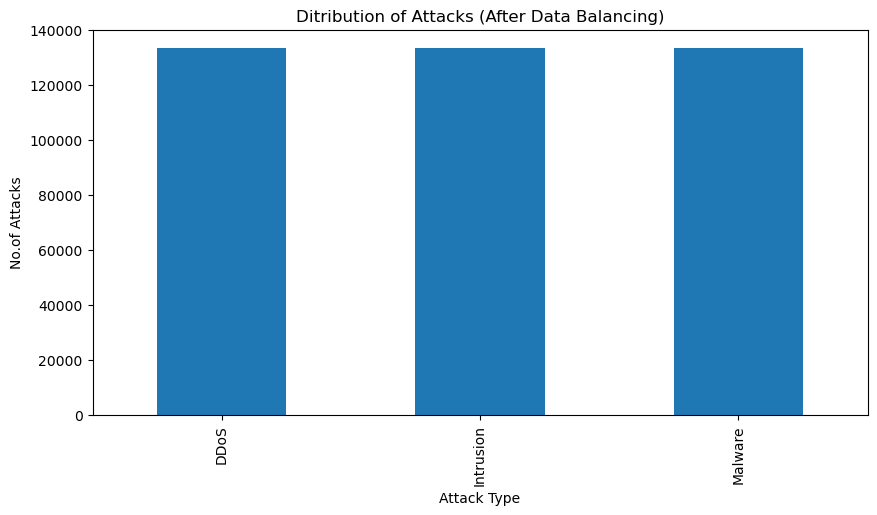

In [26]:
#Separate the Feature Variables (X) and Target/ Class Variables (y) in the Chosen Dataset
print("Dimension of the Dataset: ", df.shape)
X = df.drop(columns=['Attack Type'])
y = df['Attack Type']
print("Dimension of Feature Variables (X): ",X.shape,"Dimension of Target Variable (y): ", y.shape)
#Data balancing using SMOTE and Data Augmentation 

target_size = 200000
class_counts = y.value_counts().to_dict()
total_samples_needed = target_size - len(y)
samples_per_class = {cls: count + total_samples_needed // len(class_counts) for cls, count in class_counts.items()}

smote = SMOTE(sampling_strategy=samples_per_class, random_state=42)
X_res, y_res = smote.fit_resample(X, y)

def add_noise(dataframe, noise_level=0.01):
    noise = np.random.randn(*dataframe.shape) * noise_level
    dataframe_noisy = dataframe + noise
    return dataframe_noisy
    
numerical_columns = X_res.select_dtypes(include=[np.number]).columns
X_res_noisy = add_noise(X_res[numerical_columns])

X_augmented = pd.concat([X_res, X_res_noisy], ignore_index=True)
y_augmented = pd.concat([y_res, y_res], ignore_index=True)

df_resampled = X_augmented.copy()
df_resampled['Attack Type'] = y_augmented
df_resampled.info() #df_resampled.shape

#Number of Attack classes after Data Balancing
print("Number of Attack Classes: ",df_resampled['Attack Type'].unique())
print("\nNumber of Samples for each Attack Classes: ",df_resampled['Attack Type'].value_counts())
# Plotting the data samples after DATA BALANCING using SMOTE
plt.figure(figsize=(10,5))
df_resampled['Attack Type'].value_counts().plot(kind='bar')
plt.xticks([0,1,2], ['DDoS', 'Intrusion', 'Malware'])
plt.ylabel('No.of Attacks')
plt.title("Ditribution of Attacks (After Data Balancing)")
 
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(df_resampled.drop(columns=['Attack Type']), df_resampled['Attack Type'], test_size=0.2)
print("After Splitting the Dataset,\nDimensions of TRAINING SET: ", X_train.shape,y_train.shape)
print("Dimensions of TESTING SET: ", X_test.shape,y_test.shape)
X_train.head(2)
y_train.head(2)
X_test.head(2)
y_test.head(2)
                                            


In [27]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Convert labels to categorical format
num_classes = len(np.unique(y_train))
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)
print("After Feature Scaling,\nDimensions of TRAINING SET: ", X_train.shape,y_train.shape)
print("Dimensions of TESTING SET: ", X_test.shape,y_test.shape)

After Feature Scaling,
Dimensions of TRAINING SET:  (320000, 22) (320000, 3)
Dimensions of TESTING SET:  (80000, 22) (80000, 3)
